In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Cell 2 — Version 1: Iris dataset clustering (no labels used)
iris_data = load_iris()
X = iris_data.data

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km.fit(X_scaled)
labels = km.labels_

print(f"Inertia:         {km.inertia_:.4f}")
print(f"Silhouette Score:{silhouette_score(X_scaled, labels):.4f}")

# compare clusters vs true labels
true_labels = iris_data.target
print("\nCluster vs True Label cross-tab:")
for cluster in range(3):
    counts = np.bincount(true_labels[labels == cluster], minlength=3)
    print(f"  Cluster {cluster}: setosa={counts[0]} versicolor={counts[1]} virginica={counts[2]}")

Inertia:         139.8205
Silhouette Score:0.4599

Cluster vs True Label cross-tab:
  Cluster 0: setosa=0 versicolor=39 virginica=14
  Cluster 1: setosa=50 versicolor=0 virginica=0
  Cluster 2: setosa=0 versicolor=11 virginica=36


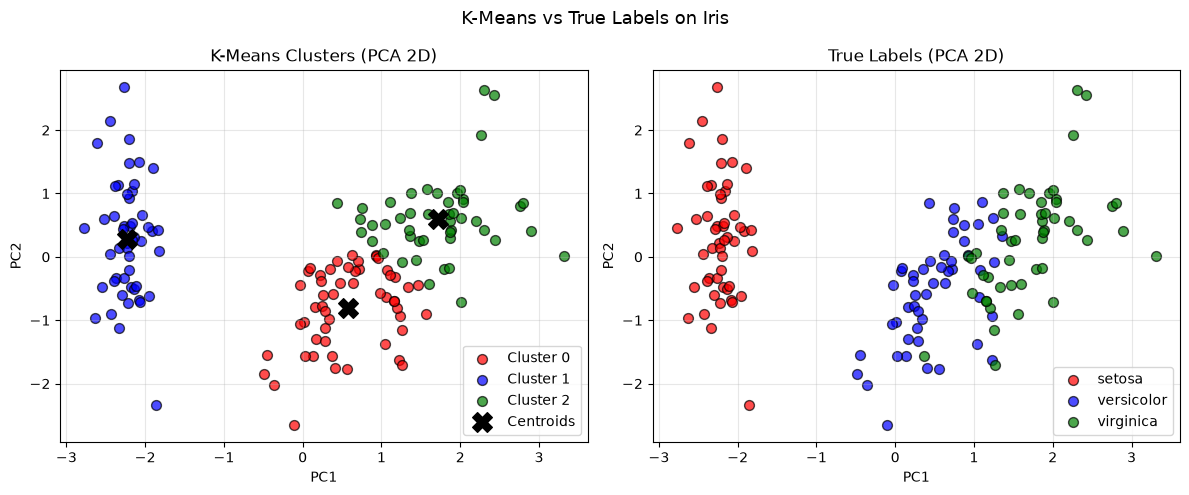

In [3]:
# Cell 3 — Version 2: PCA to 2D then visualise clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
colors = ['red', 'blue', 'green']

plt.subplot(1, 2, 1)
for k in range(3):
    mask = labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[k], s=50, label=f'Cluster {k}', edgecolors='k', alpha=0.7)
centers_pca = pca.transform(km.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', s=200, marker='X', zorder=5, label='Centroids')
plt.title('K-Means Clusters (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
true_colors = ['red', 'blue', 'green']
for k in range(3):
    mask = iris_data.target == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=true_colors[k], s=50,
                label=iris_data.target_names[k], edgecolors='k', alpha=0.7)
plt.title('True Labels (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True, alpha=0.3)

plt.suptitle('K-Means vs True Labels on Iris', fontsize=13)
plt.tight_layout(); plt.show()

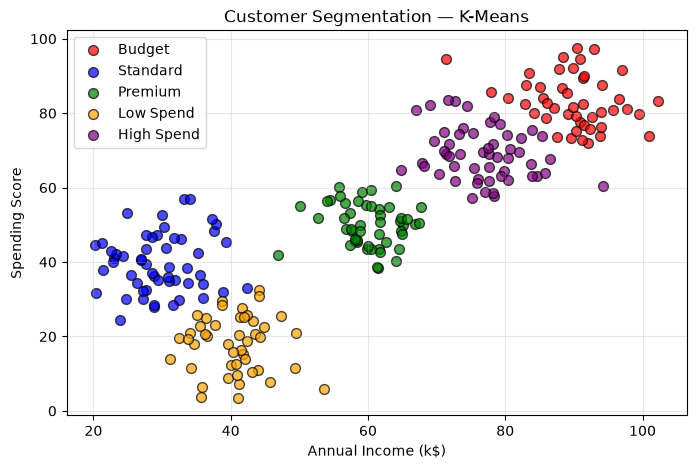

In [4]:
# Cell 4 — Version 3: customer segmentation (practical example)
np.random.seed(42)
# simulate: annual income vs spending score
income   = np.concatenate([
    np.random.normal(30, 5,  50),   # low income
    np.random.normal(60, 5,  50),   # mid income
    np.random.normal(90, 5,  50),   # high income
    np.random.normal(40, 5,  50),   # low-mid
    np.random.normal(75, 5,  50),   # high spenders
])
spending = np.concatenate([
    np.random.normal(40, 8,  50),
    np.random.normal(50, 8,  50),
    np.random.normal(80, 8,  50),
    np.random.normal(20, 8,  50),
    np.random.normal(70, 8,  50),
])
X_cust = np.column_stack([income, spending])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cust)

km = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
colors = ['red','blue','green','orange','purple']
segment_names = ['Budget','Standard','Premium','Low Spend','High Spend']
for k in range(5):
    mask = labels == k
    plt.scatter(X_cust[mask, 0], X_cust[mask, 1],
                c=colors[k], s=50, label=segment_names[k],
                edgecolors='k', alpha=0.7)
plt.xlabel('Annual Income (k$)'); plt.ylabel('Spending Score')
plt.title('Customer Segmentation — K-Means')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

In [5]:
# Cell 5 — Version 4: cluster profiling — what does each cluster look like?
iris_data = load_iris()
X = iris_data.data
feature_names = iris_data.feature_names

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
km       = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels   = km.fit_predict(X_scaled)

print("Cluster Profiles (original scale):\n")
print(f"{'Feature':30s}", end='')
for k in range(3):
    print(f"  Cluster {k}", end='')
print()
print("-"*60)
for i, feat in enumerate(feature_names):
    print(f"{feat:30s}", end='')
    for k in range(3):
        mean_val = X[labels == k, i].mean()
        print(f"  {mean_val:8.2f}", end='')
    print()

print(f"\n{'Cluster size':30s}", end='')
for k in range(3):
    print(f"  {np.sum(labels==k):8d}", end='')
print()

Cluster Profiles (original scale):

Feature                         Cluster 0  Cluster 1  Cluster 2
------------------------------------------------------------
sepal length (cm)                   5.80      5.01      6.78
sepal width (cm)                    2.67      3.43      3.10
petal length (cm)                   4.37      1.46      5.51
petal width (cm)                    1.41      0.25      1.97

Cluster size                          53        50        47
